In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [2]:
from sionnart import SionnaRT
from mobility import SionnaMobility

/home/aung/anaconda3/envs/6G/lib/python3.12/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()
/home/aung/anaconda3/envs/6G/lib/python3.12/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 NVIDIA GB10 which is of cuda capability 12.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (8.0) - (12.0)
    
  queued_call()
pybullet build time: Jan  6 2026 23:44:17


In [3]:
ASSETS = "/home/aung/code/docte6g/assets"

In [4]:
def _advance_wp(name, waypoints, idx_map):
    wps = waypoints[name]
    idx = idx_map[name]
    if idx < len(wps):
        idx_map[name] += 1
        return wps[idx]
    return wps[-1]

In [5]:
def compute_isac_metrics(detections, trajectories, agent_names, dt, match_threshold=5.0):
    """
    Greedy nearest-neighbour matching between ISAC detections and ground-truth positions.

    Returns (dr, miss_rate, fpr, frame_stats) where frame_stats is a list of
    (timestamp, frame_dr, n_false_positives) tuples.
    """
    frame_stats = []
    total_gt = total_hits = total_fp = total_dets = 0

    for frame in detections:
        t    = frame["time"]
        step = int(round(t / dt))

        gt   = [trajectories[n][step] for n in agent_names if step < len(trajectories[n])]
        gt   = np.asarray(gt)   if gt                  else np.empty((0, 3))
        dets = np.asarray(frame["positions"]) if frame["positions"] else np.empty((0, 3))

        n_gt, n_det = len(gt), len(dets)
        total_gt   += n_gt
        total_dets += n_det

        if n_gt == 0 or n_det == 0:
            frame_stats.append((t, 0.0, float(n_det)))
            total_fp += n_det
            continue

        dist = np.linalg.norm(dets[:, None, :] - gt[None, :, :], axis=-1)
        matched_gt, matched_det = set(), set()
        for _ in range(min(n_det, n_gt)):
            i, j = np.unravel_index(dist.argmin(), dist.shape)
            if dist[i, j] < match_threshold:
                matched_det.add(i)
                matched_gt.add(j)
            dist[i, :] = np.inf
            dist[:, j] = np.inf

        hits       = len(matched_gt)
        fp         = n_det - len(matched_det)
        total_hits += hits
        total_fp   += fp
        frame_stats.append((t, hits / n_gt, float(fp)))

    dr  = total_hits / total_gt   if total_gt   else 0.0
    fpr = total_fp   / total_dets if total_dets else 0.0
    return dr, 1.0 - dr, fpr, frame_stats


def plot_isac_metrics(frame_stats, dr, miss, fpr, dt, title="ISAC Metrics"):
    ts  = [f[0] for f in frame_stats]
    drs = [f[1] for f in frame_stats]
    fps = [f[2] for f in frame_stats]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

    ax1.bar(ts, drs, width=dt * 0.8, color="steelblue")
    ax1.axhline(dr, color="navy", linestyle="--", linewidth=1.5,
                label=f"mean DR = {dr:.2f}")
    ax1.set_ylim(0, 1.15)
    ax1.set_ylabel("detection rate")
    ax1.set_title(f"{title}  |  DR = {dr:.2f}   Miss = {miss:.2f}   FPR = {fpr:.2f}")
    ax1.legend()
    ax1.grid(True, axis="y")

    ax2.bar(ts, fps, width=dt * 0.8, color="crimson")
    ax2.set_ylabel("# false positives")
    ax2.set_xlabel("time (s)")
    ax2.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax2.grid(True, axis="y")

    plt.tight_layout()
    plt.show()

# Free Space

### Configurations

In [6]:
_UE_SPEED = 2.0
_INTERVAL = 0.5
_MTI_THRESHOLD = (_UE_SPEED * _INTERVAL / 2) - 0.1

UE_START = [
    [-5.0, 10.0, 1.5],
    [0.0, 15.0, 1.5],
    [5.0, 20.0, 1.5]
]

radio_settings = {
    # NR
    "scene": f"{ASSETS}/scenes/free_space/free_space.xml",
    "carrier_frequency": 3.5e9,
    "subcarrier_spacing": 30000,
    "num_subcarriers": 3276,
    "tx_num_rows": 8, "tx_num_rows": 8,
    "rx_num_rows": 2, "rx_num_rows": 2,
    "pattern": "tr38901",
    "polarization": "VH",
    "tx_locations": [[0.0, 0.0, 10.0]],
    "tx_names": ["gNB"],
    "tx_ids": [0],
    "tx_power": 46.0,
    "rx_locations": UE_START,
    "rx_names": ["ue_1", "ue_2", "ue_3"],
    "rx_ids": [1, 2, 3],
    "rx_speed": [_UE_SPEED] * 3,
    "rx_mesh": f"{ASSETS}/objects/iw_hub/iw_hub.ply",
    "rx_update_interval": _INTERVAL,
    "simulation_duration": 15.0,

    # ISAC
    "enable_situation_awareness": True,
    "rx_type_path": f"{ASSETS}/objects/iw_hub/iw_hub.ply",
    "isac_min_power": 1e-25,
    "isac_eps_cluster": 1.5,
    "isac_mti_dist_threshold": _MTI_THRESHOLD,
    "isac_rx_scattering_coefficient": 0.5,
    "isac_min_displacement": 0.3,
    "isac_beamwidth_deg": 20.0,
    "isac_max_depth": 3,
    "isac_diffuse_reflection": True,
    "isac_samples_per_src": 2_000_000,
    "isac_single_bounce_only": False,
    "isac_mti_warmup_frames": 0,
}

mobility_settings = {
    "scene": f"{ASSETS}/scenes/free_space/free_space.obj",
    "tx_locations": radio_settings["tx_locations"],
    "tx_names": radio_settings["tx_names"],
    "tx_ids": radio_settings["tx_ids"],
    "tx_modes": ["CONSTANT_POSITION"],
    "tx_power": radio_settings["tx_power"],
    "rx_locations": [[p[0], p[1], 0.0] for p in UE_START],
    "rx_names": radio_settings["rx_names"],
    "rx_ids": radio_settings["rx_ids"],
    "rx_modes": ["WAYPOINT"] * 3,
    "rx_speed": radio_settings["rx_speed"],
    "rx_mesh": f"{ASSETS}/objects/iw_hub/iw_hub.obj"
}

### Instantiation

In [7]:
sionnart = SionnaRT()
sionnart.initialize(radio_settings)

mobility = SionnaMobility()
mobility.initialize(mobility_settings)

assert sionnart.enable_SA, "ISAC must be enabled"
print("ISAC calibration:", sionnart.calib)

ISAC calibration: {'eps_cluster': 1.5, 'z_min': 0.884299099445343, 'z_max': 2.347102701663971, 'min_power': 1e-25, 'bbox_size': array([1.43085217, 0.65968287, 0.2314018 ])}


### Simulation

In [8]:
UE_WAYPOINTS = {
    "ue_1": [[-5.0, 10.0], [ 5.0, 14.0], [-5.0, 18.0], [ 5.0, 22.0], [ 0.0, 26.0]],
    "ue_2": [[ 0.0, 15.0], [-8.0, 19.0], [ 2.0, 23.0], [-5.0, 27.0], [ 0.0, 30.0]],
    "ue_3": [[ 5.0, 20.0], [-3.0, 24.0], [ 7.0, 27.0], [ 0.0, 30.0], [ 5.0, 33.0]],
}

ues               = radio_settings["rx_names"]
rx_height         = 1.5
trajectories      = {name: [] for name in ues}
rx_update_interval = float(radio_settings["rx_update_interval"])
num_steps          = max(1, int(float(radio_settings["simulation_duration"]) / rx_update_interval))
wp_idx             = {name: 1 for name in ues}

current_dest = {name: UE_WAYPOINTS[name][1] for name in ues}
for name in ues:
    d = current_dest[name]
    mobility.set_destination(name, [d[0], d[1], 0.0])

all_records = []
for step in range(num_steps):
    timestamp = step * rx_update_interval
    for name in ues:
        pos = mobility.update_position(name, timestamp)
        if pos is not None:
            sionnart.update_position(name, [pos[0], pos[1], rx_height])
            trajectories[name].append([pos[0], pos[1], rx_height])
            dest = current_dest[name]
            if np.hypot(pos[0] - dest[0], pos[1] - dest[1]) < 1.5:
                nxt = _advance_wp(name, UE_WAYPOINTS, wp_idx)
                mobility.set_destination(name, [nxt[0], nxt[1], 0.0])
                current_dest[name] = nxt
    records = sionnart.perform_calculation(timestamp)
    all_records.extend(records)

perf       = sionnart.get_perf_stats()
detections = sionnart.get_detected_objects()
print(f"Propagation records : {len(all_records)}")
print(f"Detection frames    : {len(detections)}")
print(f"Frames with tracks  : {sum(1 for d in detections if d['positions'])}")
print(f"Path-solve seconds  : {perf.get('python_path_solve_seconds', 0.0):.3f}")
print(f"ISAC pre-pass sec   : {perf.get('python_isac_pre_seconds', 0.0):.3f}")

Propagation records : 300
Detection frames    : 30
Frames with tracks  : 28
Path-solve seconds  : 0.408
ISAC pre-pass sec   : 0.553


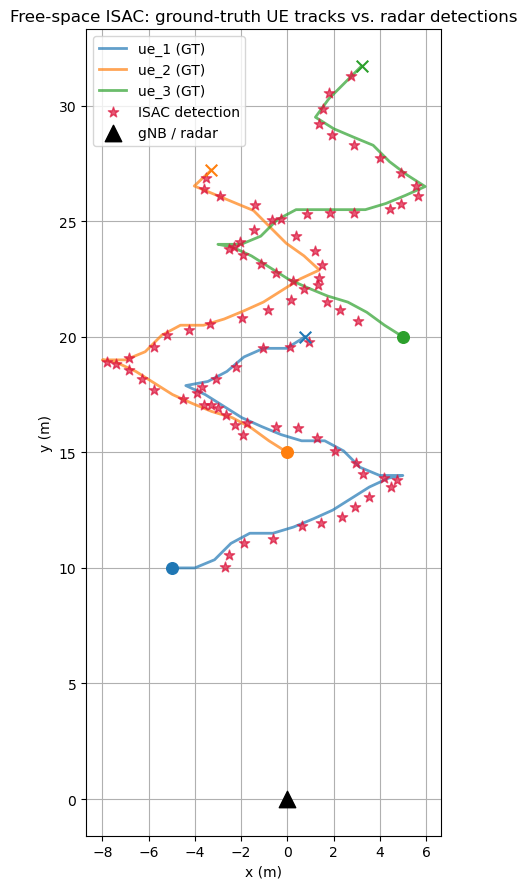

In [9]:
colors = {"ue_1": "tab:blue", "ue_2": "tab:orange", "ue_3": "tab:green"}

fig, ax = plt.subplots(figsize=(9, 9))

# Ground-truth trajectories
for name, pts in trajectories.items():
    if not pts:
        continue
    pts = np.array(pts)
    ax.plot(pts[:, 0], pts[:, 1], color=colors.get(name, "gray"),
            label=f"{name} (GT)", linewidth=2, alpha=0.7)
    ax.scatter(pts[0, 0], pts[0, 1], color=colors.get(name, "gray"),
               marker="o", s=70, zorder=5)
    ax.scatter(pts[-1, 0], pts[-1, 1], color=colors.get(name, "gray"),
               marker="x", s=70, zorder=5)

# ISAC detections across all frames
det_xy = []
for frame in detections:
    for p in frame["positions"]:
        det_xy.append(p[:2])
if det_xy:
    det_xy = np.array(det_xy)
    ax.scatter(det_xy[:, 0], det_xy[:, 1], marker="*", color="crimson",
               s=60, alpha=0.7, label="ISAC detection", zorder=4)

gnb = radio_settings["tx_locations"][0]
ax.scatter(gnb[0], gnb[1], color="black", marker="^", s=140,
           zorder=6, label="gNB / radar")

ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Free-space ISAC: ground-truth UE tracks vs. radar detections")
ax.legend(loc="best")
ax.grid(True)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

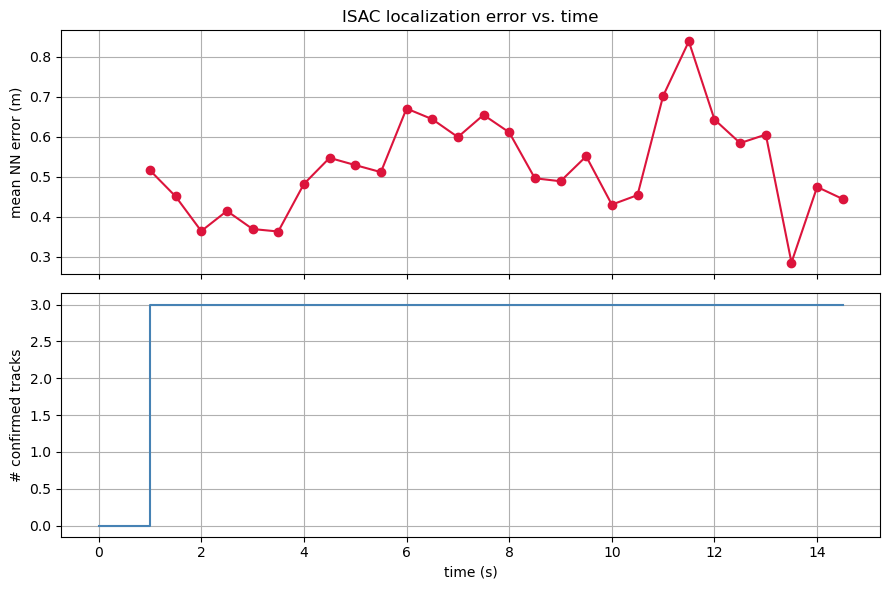

In [10]:
times, errors, counts = [], [], []
for frame in detections:
    t = frame["time"]
    step = int(round(t / rx_update_interval))
    gt = []
    for name in ues:
        if step < len(trajectories[name]):
            gt.append(trajectories[name][step])
    if not gt or not frame["positions"]:
        times.append(t); errors.append(np.nan); counts.append(len(frame["positions"]))
        continue
    gt = np.asarray(gt)
    dets = np.asarray(frame["positions"])
    d = np.linalg.norm(dets[:, None, :] - gt[None, :, :], axis=-1).min(axis=1)
    times.append(t); errors.append(float(d.mean())); counts.append(len(frame["positions"]))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
ax1.plot(times, errors, marker="o", color="crimson")
ax1.set_ylabel("mean NN error (m)")
ax1.set_title("ISAC localization error vs. time")
ax1.grid(True)
ax2.step(times, counts, where="post", color="steelblue")
ax2.set_ylabel("# confirmed tracks")
ax2.set_xlabel("time (s)")
ax2.grid(True)
plt.tight_layout()
plt.show()

In [11]:
MATCH_THRESHOLD_M = 1.0

dr, miss, fpr, frame_stats = compute_isac_metrics(
    detections, trajectories, ues, rx_update_interval, MATCH_THRESHOLD_M
)

print(f"Match threshold : {MATCH_THRESHOLD_M} m")
print(f"Detection rate  : {dr:.3f}  ({dr * 100:.1f}%)")
print(f"Miss rate       : {miss:.3f}  ({miss * 100:.1f}%)")
print(f"False-pos rate  : {fpr:.3f}  ({fpr * 100:.1f}%)")

Match threshold : 1.0 m
Detection rate  : 0.900  (90.0%)
Miss rate       : 0.100  (10.0%)
False-pos rate  : 0.036  (3.6%)


# Warehouse

### Configurations

In [12]:
_WH_UE_SPEED = 2.0
_WH_INTERVAL = 0.5
_WH_MTI = (_WH_UE_SPEED * _WH_INTERVAL / 2) - 0.1

WH_START = [
    [11.5,  9.0, 1.5],   # robot_1 — Arm1, south approach (LOS clear)
    [11.5,  4.0, 1.5],   # robot_2 — Arm2, south approach (LOS clear)
    [11.5, -1.0, 1.5],   # robot_3 — Arm3, north approach (LOS blocked by rack)
]

wh_radio_settings = {
    #NR
    "scene": f"{ASSETS}/scenes/warehouse/warehouse.xml",
    "carrier_frequency": 15e9,
    "subcarrier_spacing": 120_000,
    "num_subcarriers": 3276,
    "tx_num_rows": 8,  "tx_num_cols": 8,
    "rx_num_rows": 2,  "rx_num_cols": 2,
    "pattern": "tr38901",
    "polarization": "VH",
    "tx_locations": [[14.0, -11.0, 3.0]],  # single gNB, bottom-right corner
    "tx_names":   ["gNB"],
    "tx_ids":     [0],
    "tx_look_at": [[0.0, 0.0, 1.5]],
    "tx_power": 46.0,
    "rx_locations": WH_START,
    "rx_names": ["robot_1", "robot_2", "robot_3"],
    "rx_ids":   [1, 2, 3],
    "rx_speed": [_WH_UE_SPEED] * 3,
    "rx_mesh":  f"{ASSETS}/objects/iw_hub/iw_hub.ply",
    "rx_update_interval": _WH_INTERVAL,
    "simulation_duration": 30.0,
    
    # ISAC
    "enable_situation_awareness": True,
    "rx_type_path": f"{ASSETS}/objects/iw_hub/iw_hub.ply",
    "isac_min_power": 1e-25,
    "isac_eps_cluster": 1.5,
    "isac_mti_dist_thresh": _WH_MTI,
    "isac_rx_scattering_coefficient": 0.5,
    "isac_min_displacement": 0.3,
    "isac_beamwidth_deg": 20.0,
    "isac_max_depth": 3,
    "isac_diffuse_reflection": True,
    "isac_samples_per_src": 2_000_000,
    "isac_single_bounce_only": False,
    "isac_tracker_min_age": 2,
    "isac_mti_warmup_frames": 0,
}

wh_mobility_settings = {
    "scene": f"{ASSETS}/scenes/warehouse/warehouse.obj",
    "tx_locations": wh_radio_settings["tx_locations"],
    "tx_names": wh_radio_settings["tx_names"],
    "tx_ids": wh_radio_settings["tx_ids"],
    "tx_modes": ["CONSTANT_POSITION"],
    "tx_power": wh_radio_settings["tx_power"],
    "rx_locations": [[p[0], p[1], 0.0] for p in WH_START],
    "rx_names": wh_radio_settings["rx_names"],
    "rx_ids": wh_radio_settings["rx_ids"],
    "rx_modes": ["WAYPOINT"] * 3,
    "rx_speed": wh_radio_settings["rx_speed"],
    "rx_mesh": f"{ASSETS}/objects/iw_hub/iw_hub.obj",
}

### Instantiation

In [13]:
wh_sionnart = SionnaRT()
wh_sionnart.initialize(wh_radio_settings)

wh_mobility = SionnaMobility()
wh_mobility.initialize(wh_mobility_settings)

assert wh_sionnart.enable_SA, "ISAC must be enabled"
print("Warehouse ISAC calibration:", wh_sionnart.calib)


Warehouse ISAC calibration: {'eps_cluster': 1.5, 'z_min': 0.884299099445343, 'z_max': 2.347102701663971, 'min_power': 1e-25, 'bbox_size': array([1.43085217, 0.65968287, 0.2314018 ])}


### Simulation

In [14]:
WH_WAYPOINTS = {
    "robot_1": [[11.5,  9.0], [11.5, -8.0], [-12.0, -8.0], [-12.0, -7.0]],
    "robot_2": [[11.5,  4.0], [11.5, -8.0], [ -7.0, -8.0], [ -7.0, -7.0]],
    "robot_3": [[11.5, -1.0], [ 2.0, -1.0], [ -2.0, -1.0], [ -2.0, -3.0]],
}

robots             = wh_radio_settings["rx_names"]
rx_height          = 1.5
wh_trajectories    = {name: [] for name in robots}
rx_update_interval = float(wh_radio_settings["rx_update_interval"])
num_steps          = max(1, int(float(wh_radio_settings["simulation_duration"]) / rx_update_interval))
wp_idx             = {name: 1 for name in robots}

current_dest = {name: WH_WAYPOINTS[name][1] for name in robots}
for name in robots:
    d = current_dest[name]
    wh_mobility.set_destination(name, [d[0], d[1], 0.0])

wh_all_records = []
for step in range(num_steps):
    timestamp = step * rx_update_interval
    for name in robots:
        pos = wh_mobility.update_position(name, timestamp)
        if pos is not None:
            wh_sionnart.update_position(name, [pos[0], pos[1], rx_height])
            wh_trajectories[name].append([pos[0], pos[1], rx_height])
            dest = current_dest[name]
            if np.hypot(pos[0] - dest[0], pos[1] - dest[1]) < 1.5:
                nxt = _advance_wp(name, WH_WAYPOINTS, wp_idx)
                wh_mobility.set_destination(name, [nxt[0], nxt[1], 0.0])
                current_dest[name] = nxt
    records = wh_sionnart.perform_calculation(timestamp)
    wh_all_records.extend(records)

perf          = wh_sionnart.get_perf_stats()
wh_detections = wh_sionnart.get_detected_objects()
print(f"Propagation records : {len(wh_all_records)}")
print(f"Detection frames    : {len(wh_detections)}")
print(f"Frames with tracks  : {sum(1 for d in wh_detections if d['positions'])}")
print(f"Path-solve seconds  : {perf.get('python_path_solve_seconds', 0.0):.3f}")
print(f"ISAC pre-pass sec   : {perf.get('python_isac_pre_seconds', 0.0):.3f}")

Propagation records : 690
Detection frames    : 60
Frames with tracks  : 59
Path-solve seconds  : 8.340
ISAC pre-pass sec   : 2.714


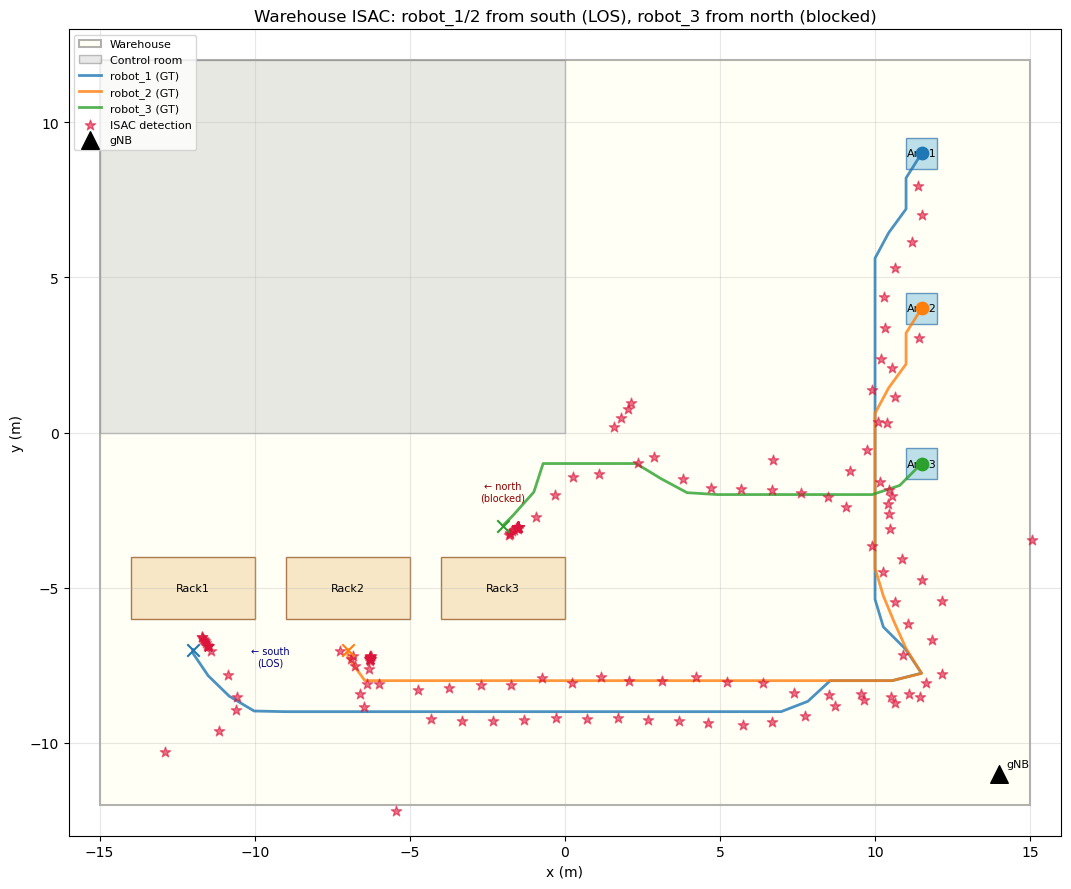

In [15]:
colors = {"robot_1": "tab:blue", "robot_2": "tab:orange", "robot_3": "tab:green"}

fig, ax = plt.subplots(figsize=(12, 9))

ax.add_patch(mpatches.Rectangle((-15, -12), 30, 24, linewidth=1.5,
             edgecolor="black", facecolor="lightyellow", alpha=0.3, label="Warehouse"))
ax.add_patch(mpatches.Rectangle((-15, 0), 15, 12, linewidth=1,
             edgecolor="gray", facecolor="lightgray", alpha=0.5, label="Control room"))

for rx, ry, rlabel in [(-14, -6, "Rack1"), (-9, -6, "Rack2"), (-4, -6, "Rack3")]:
    ax.add_patch(mpatches.Rectangle((rx, -6), 4, 2, linewidth=1,
                 edgecolor="saddlebrown", facecolor="wheat", alpha=0.7))
    ax.text(rx + 2, ry + 1, rlabel, ha="center", va="center", fontsize=8)

for ax_, ay, alabel in [(11, 8.5, "Arm1"), (11, 3.5, "Arm2"), (11, -1.5, "Arm3")]:
    ax.add_patch(mpatches.Rectangle((ax_, ay), 1, 1, linewidth=1,
                 edgecolor="steelblue", facecolor="lightblue", alpha=0.8))
    ax.text(ax_ + 0.5, ay + 0.5, alabel, ha="center", va="center", fontsize=8)

for name, pts in wh_trajectories.items():
    if not pts: continue
    pts = np.array(pts)
    ax.plot(pts[:, 0], pts[:, 1], color=colors[name], linewidth=2, alpha=0.8,
            label=f"{name} (GT)")
    ax.scatter(pts[0, 0], pts[0, 1], color=colors[name], marker="o", s=80, zorder=5)
    ax.scatter(pts[-1, 0], pts[-1, 1], color=colors[name], marker="x", s=80, zorder=5)

det_xy = [p[:2] for frame in wh_detections for p in frame["positions"]]
if det_xy:
    det_xy = np.array(det_xy)
    ax.scatter(det_xy[:, 0], det_xy[:, 1], marker="*", color="crimson",
               s=60, alpha=0.6, label="ISAC detection", zorder=4)

gnb = wh_radio_settings["tx_locations"][0]
ax.scatter(gnb[0], gnb[1], color="black", marker="^", s=160, zorder=6, label="gNB")
ax.annotate("gNB", (gnb[0], gnb[1]), textcoords="offset points", xytext=(5, 5), fontsize=8)

# Annotate approach directions
ax.annotate("← south\n(LOS)", xy=(-9.5, -7.5), fontsize=7, color="navy", ha="center")
ax.annotate("← north\n(blocked)", xy=(-2, -2.2), fontsize=7, color="darkred", ha="center")

ax.set_xlim(-16, 16); ax.set_ylim(-13, 13)
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
ax.set_title("Warehouse ISAC: robot_1/2 from south (LOS), robot_3 from north (blocked)")
ax.legend(loc="upper left", fontsize=8)
ax.grid(True, alpha=0.3); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

In [16]:
MATCH_THRESHOLD_M = 1.0

wh_dr, wh_miss, wh_fpr, wh_frame_stats = compute_isac_metrics(
    wh_detections, wh_trajectories, robots, rx_update_interval, MATCH_THRESHOLD_M
)

print(f"Match threshold : {MATCH_THRESHOLD_M} m")
print(f"Detection rate  : {wh_dr:.3f}  ({wh_dr * 100:.1f}%)")
print(f"Miss rate       : {wh_miss:.3f}  ({wh_miss * 100:.1f}%)")
print(f"False-pos rate  : {wh_fpr:.3f}  ({wh_fpr * 100:.1f}%)")

Match threshold : 1.0 m
Detection rate  : 0.894  (89.4%)
Miss rate       : 0.106  (10.6%)
False-pos rate  : 0.374  (37.4%)
